# StateSqft — confusion matrix & metrics

This notebook mirrors the **baseline models** in `scripts/baseline.py`:

- **Classification:** predict whether **next month’s for-sale inventory** is **higher** than this month (`target_next_mom_up`: 0 = down/same, 1 = up).
- **Regression:** predict **next month’s inventory level** (`target_next_inv`).

We show a **confusion matrix** (heatmap), **accuracy / precision / recall / F1 / ROC-AUC**, and regression **RMSE, MAE, R²**.

**Data:** `Metro_invt_fs_uc_sfrcondo_sm_month.csv` at the **repository root** (see `bia652p.config.DATA_CSV`).

**Run:** from repo root, `pip install -e .` then `jupyter notebook notebooks/metrics_confusion_matrix.ipynb` (install `jupyter ipykernel` if needed). Execute cells top to bottom.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Resolve repo root (works if cwd is repo root or notebooks/)
_cwd = Path.cwd().resolve()
ROOT = _cwd if (_cwd / "src" / "bia652p").is_dir() else _cwd.parent
if not (ROOT / "src" / "bia652p").is_dir():
    raise FileNotFoundError(
        f"Could not find src/bia652p under {ROOT}. Open/run the notebook from the repository."
    )
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from bia652p.data.load import load_wide, melt_inventory_long, profile_dataset
from bia652p.evaluate import classification_metrics, classification_metrics_proba, regression_metrics
from bia652p.features import add_lags_and_targets, add_time_features, time_based_split
from IPython.display import display

%matplotlib inline
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("default")
RANDOM_STATE = 42

In [2]:
FEATURE_COLS = [
    "inv_lag_1",
    "inv_lag_2",
    "inv_lag_3",
    "month_sin",
    "month_cos",
    "SizeRank",
]

print("Loading CSV…")
wide = load_wide()
long_df = melt_inventory_long(wide)
print("Dataset profile:", profile_dataset(long_df))

long_df = add_time_features(long_df)
long_df = add_lags_and_targets(long_df, lag_months=(1, 2, 3))

modeling = long_df.dropna(subset=FEATURE_COLS + ["target_next_inv", "target_next_mom_up"]).copy()
modeling["target_next_mom_up"] = modeling["target_next_mom_up"].astype(int)

print(f"Rows after dropping missing lags/targets: {len(modeling):,}")
vc = modeling["target_next_mom_up"].value_counts().sort_index()
display(vc.to_frame("count").assign(percent=lambda d: (100 * d["count"] / len(modeling)).round(2)))

train_df, test_df = time_based_split(modeling, test_fraction=0.2)
print(f"Time split — train rows: {len(train_df):,}, test rows: {len(test_df):,}")

X_train, X_test = train_df[FEATURE_COLS], test_df[FEATURE_COLS]
y_reg_train = train_df["target_next_inv"].values
y_reg_test = test_df["target_next_inv"].values
y_cls_train = train_df["target_next_mom_up"].values
y_cls_test = test_df["target_next_mom_up"].values

Loading CSV…
Dataset profile: {'n_rows': 89088, 'n_metros': 928, 'date_min': Timestamp('2018-03-31 00:00:00'), 'date_max': Timestamp('2026-02-28 00:00:00'), 'inventory_missing_pct': 1.3368803879310345, 'inventory_min': 4.0, 'inventory_max': 1733393.0, 'inventory_mean': 2500.4790379648907}
Rows after dropping missing lags/targets: 84,045


,count,percent
target_next_mom_up,,
0,45545,54.19
1,38500,45.81


Time split — train rows: 67,341, test rows: 16,704


## 1. Classification — logistic regression

Same settings as `scripts/baseline.py`: standardized features, `class_weight="balanced"`.

In [3]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

clf = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
clf.fit(X_train_s, y_cls_train)
pred_cls = clf.predict(X_test_s)
proba_cls = clf.predict_proba(X_test_s)[:, 1]

cls_scores = classification_metrics(y_cls_test, pred_cls)
cls_scores.update(classification_metrics_proba(y_cls_test, proba_cls))

metrics_df = pd.DataFrame([cls_scores]).T
metrics_df.columns = ["value"]
display(metrics_df.round(4))

,value
accuracy,0.7517
precision,0.8325
recall,0.5882
f1,0.6893
roc_auc,0.8535


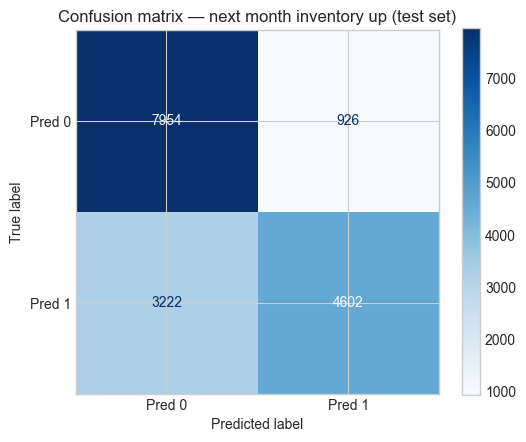

Confusion matrix [rows = true, cols = predicted]:
[[7954  926]
 [3222 4602]]


In [4]:
cm = confusion_matrix(y_cls_test, pred_cls)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Pred 0", "Pred 1"])
disp.plot(ax=ax, cmap="Blues", colorbar=True, values_format="d")
ax.set_title("Confusion matrix — next month inventory up (test set)")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
plt.tight_layout()
plt.show()

print("Confusion matrix [rows = true, cols = predicted]:")
print(cm)

In [5]:
print(classification_report(y_cls_test, pred_cls, digits=4, target_names=["down/same", "up"]))

              precision    recall  f1-score   support

   down/same     0.7117    0.8957    0.7932      8880
          up     0.8325    0.5882    0.6893      7824

    accuracy                         0.7517     16704
   macro avg     0.7721    0.7420    0.7413     16704
weighted avg     0.7683    0.7517    0.7445     16704



## 2. Regression — linear regression (next-month level)

Predict continuous **next month inventory**; metrics are **RMSE, MAE, R²** on the held-out time window.

,value
rmse,1780.7205
mae,131.5686
r2,0.9981


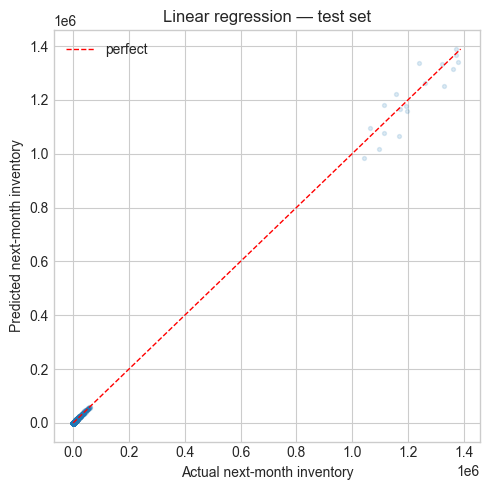

In [6]:
reg = LinearRegression()
reg.fit(X_train_s, y_reg_train)
pred_reg = reg.predict(X_test_s)
reg_scores = regression_metrics(y_reg_test, pred_reg)

reg_df = pd.DataFrame([reg_scores]).T
reg_df.columns = ["value"]
display(reg_df.round(4))

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_reg_test, pred_reg, alpha=0.15, s=8)
lim = [min(y_reg_test.min(), pred_reg.min()), max(y_reg_test.max(), pred_reg.max())]
ax.plot(lim, lim, "r--", lw=1, label="perfect")
ax.set_xlabel("Actual next-month inventory")
ax.set_ylabel("Predicted next-month inventory")
ax.set_title("Linear regression — test set")
ax.legend()
plt.tight_layout()
plt.show()